<a href="https://colab.research.google.com/github/Edwinshajan2006/data-science-/blob/main/cluster_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("//content/Insurance_Customer Data.csv")

In [ ]:
df

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3
...,...,...,...,...,...,...,...
655,656,51108,99000,10,1,10,0
656,657,60732,84000,10,1,13,2
657,658,53834,145000,8,1,9,1
658,659,80655,172000,10,1,15,0


In [ ]:
df.isna().sum()

,0
Sl_No,0
Customer Key,0
Avg_Credit_Limit,0
Total_Credit_Cards,0
Total_visits_bank,0
Total_visits_online,0
Total_calls_made,0


In [ ]:
df.shape

(660, 7)

In [ ]:
df=df.dropna()

In [ ]:
df.columns

Index(['Sl_No', 'Customer Key', 'Avg_Credit_Limit', 'Total_Credit_Cards',
       'Total_visits_bank', 'Total_visits_online', 'Total_calls_made'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df_scaled=sc.fit_transform(df.drop('Sl_No',axis=1))

In [ ]:
from  sklearn.cluster import KMeans
wcss=[]
for i in range(2,11):
  kmeans=KMeans(n_clusters=i,random_state=42)
  kmeans.fit(df_scaled)
  wcss.append(kmeans.inertia_)

In [ ]:
wcss

[2700.9848113806484,
 1592.8133253795975,
 1309.5101821443154,
 1219.2651025637583,
 1051.1467852335695,
 989.5914937101331,
 969.4488665345111,
 946.6761863268147,
 903.2217262423649]

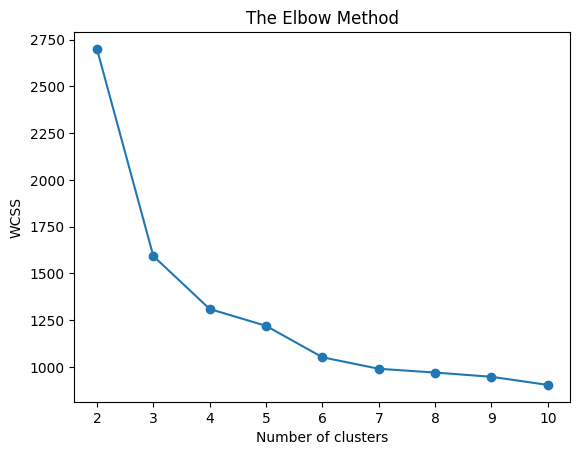

In [ ]:
plt.plot(range(2,11),wcss,marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
kmeans=KMeans(n_clusters=5,random_state=42)
df['cluster']=kmeans.fit_predict(df_scaled)

In [ ]:
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,cluster
0,1,87073,100000,2,1,1,0,1
1,2,38414,50000,3,0,10,9,2
2,3,17341,50000,7,1,3,4,0
3,4,40496,30000,5,1,1,4,0
4,5,47437,100000,6,0,12,3,3


<Axes: xlabel='cluster', ylabel='count'>

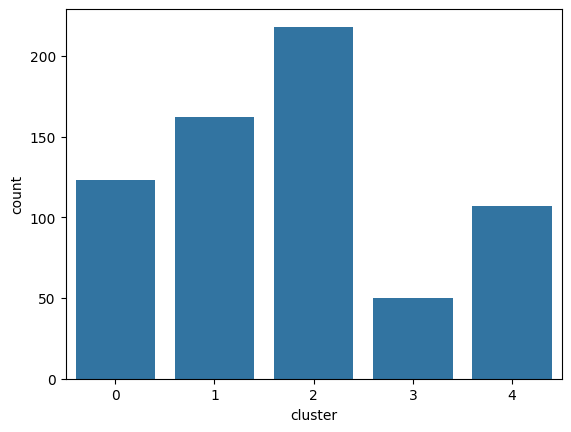

In [ ]:
sns.countplot(x=df['cluster'])

In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
df_pca=pca.fit_transform(df.drop('Sl_No',axis=1))

/tmp/ipykernel_5866/2701153622.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


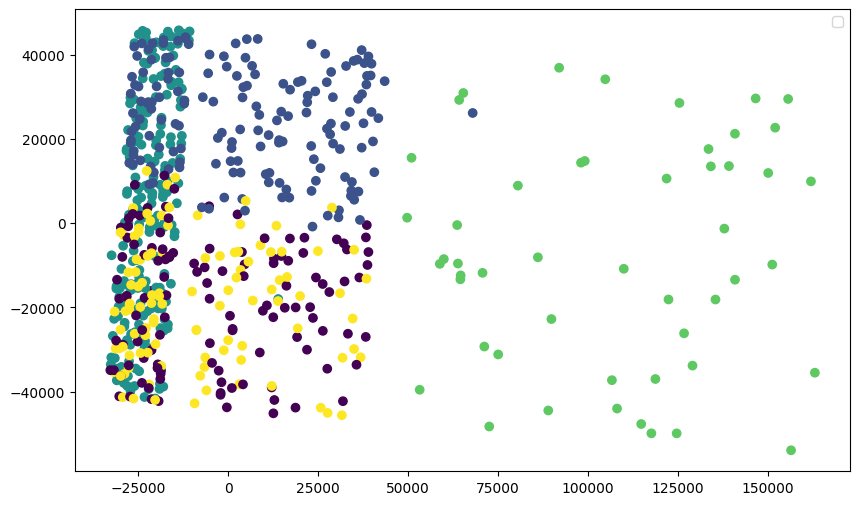

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(df_pca[:,0],df_pca[:,1],c=df['cluster'])
plt.legend()
plt.show()